# übung 2 #

In [2]:
import matplotlib.pyplot as plt
from skimage import io
import numpy as np

c:\Users\Ann-Kathrin\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\Ann-Kathrin\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\Ann-Kathrin\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [12]:
##2 beide Bilder einlesen
pfad = "C:/Users/Ann-Kathrin/Desktop/htwg/semester05/2DCV/uebung2/"
dateien = ["bild01.jpg", "bild02.jpg"] 

bilder = [io.imread(pfad + name) for name in dateien]

bild01 = io.imread(pfad + dateien [0])
bild02 = io.imread(pfad + dateien [1])

In [13]:
## bilder in graustufen bild umwandeln
def bunt_zu_grau(image):
    gray = (
        0.299 * image[:, :, 0] +
        0.587 * image[:, :, 1] +
        0.114 * image[:, :, 2]
    )
    return gray.astype(np.uint8)

bild01_grau = bunt_zu_grau(bild01)
bild02_grau = bunt_zu_grau(bild02)

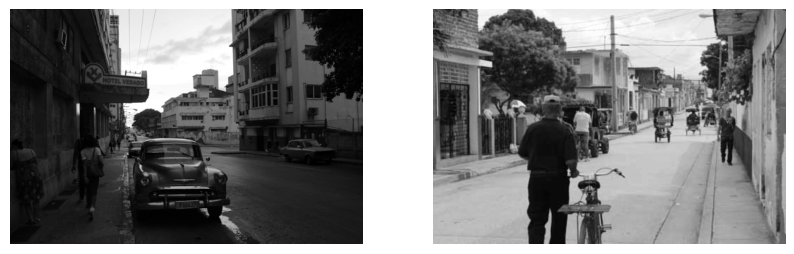

In [26]:
plt.figure(figsize=(10,8))

plt.subplot(1,2,1)
plt.imshow(bild01_grau, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(bild02_grau, cmap='gray')
plt.axis("off")

plt.show()

In [27]:
#histogramm 
def computeHisto(image):
    #falls bunt -> grau
    if len(image.shape) == 3:
        image = bunt_zu_grau(image)

    histo = np.zeros(256, dtype=int)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            histo[image[y, x]] += 1

    return histo

In [33]:
# kumulatives histogramm
def computecumHisto(image, binSize = 256):
    histo = computecumHisto(image)

    #normieren
    histo = histo / np.sum(histo)

    #kumulieren
    cumHisto = cumHisto / np.sum(cumHisto)

    return cumHisto


Aufgabe 3 <br>
a) Unterschied homogene und nicht-homogene Punktoperation <br>
Homogene Punktoperation ist unabhänig von den Bildkoordinaten
Nicht-homogene Punktoperationen ist abhäning von der Position, Transformation ist nicht für alle Pixel gleich. <br>
b) Unterschied zwischen Punktoperationen und Filteroperationen? <br>
Bei Punktoperationen werden die Pixel unabhäning voneinander berücksichtigt <br> bei Filteroperationen bezieht die Umgebung eines Pixels mit ein (zb Glättung)

In [39]:
# LookUpTable
def match_Histo(img_histo, ref_histo):
    # Normieren
    img_histo = img_histo / np.sum(img_histo)
    ref_histo = ref_histo / np.sum(ref_histo)

    # kumulatives histogramme
    img_cum = np.cumsum(img_histo)
    ref_cum = np.cumsum(ref_histo)

    LUT = np.zeros(256, dtype=np.uint8)

    j = 0
    for i in range(256):
        while j < 255 and ref_cum[j] < img_cum[i]:
            j += 1
        LUT[i] = j

    return LUT

In [40]:
def apply_LUT(image, LUT):
    result = np.zeros_like(image)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            result[y, x] = LUT[image[y, x]]

    return result

In [50]:
histo1 = computeHisto(bild01_grau)
histo2 = computeHisto(bild02_grau)

# cum1 = computecumHisto(bild01_grau)
# cum2 = computecumHisto(bild02_grau)

LUT = match_Histo(histo1, histo2)

bild01_matched = apply_LUT(bild01_grau, LUT)

#cum_matched = computecumHisto(bild01_matched)

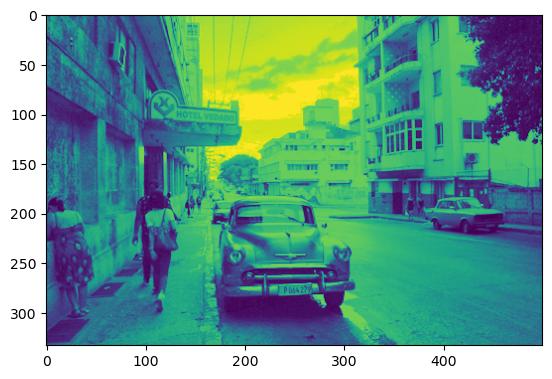

In [51]:
plt.imshow(bild01_matched)